<a href="https://colab.research.google.com/github/fabri-marques/cv-coursework/blob/main/aviii_filtros_fr/visao_computacional_aviii_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade III: Filtragem de Imagens e Análise de Ruído
*Por* **Fabricia Cristina Marques Jung**

Visão Computacional, Residência em TIC43. Unidade 2, Capítulo 1, Tarefa 3.


## Objetivo e Enunciado

#### Objetivo

Aplicar técnicas fundamentais de filtragem no domínio da frequência e de análise de ruído,
explorando na prática:

* Inserção de ruído gaussiano
* Inserção de ruído sal e pimenta
* Filtros passa-baixo (suavização)
* Filtros passa-alto (realce de bordas e detalhes)
* Avaliação do impacto desses processos em imagens usadas em Visão Computacional

A atividade reutiliza o mini dataset criado pelo próprio aluno na Unidade 1, Capítulo 1,
Tarefa 2. A meta é compreender como ruídos e filtros afetam a qualidade da imagem e o
desempenho potencial de algoritmos de visão computacional, uma etapa essencial em pipelines
reais de VC.


#### Enunciado

Utilizando o mini dataset criado na atividade anterior, aplicar diferentes tipos de ruído
artificial e, em seguida, realizar a filtragem das imagens para observar como esses filtros
atuam na redução de ruído e na preservação ou realce de detalhes. A atividade é desenvolvida
neste Jupyter Notebook, contendo código, imagens resultantes e análises, seguindo as cinco
partes do enunciado:

1. Seleção das imagens (uma da Classe A e uma da Classe B)
2. Inserção de ruído (gaussiano e sal e pimenta)
3. Filtro passa-baixo em dois níveis de suavização
4. Filtro passa-alto para realce de bordas
5. Comparação final e análise técnica


## Execução e relatório

In [5]:
# Ambiente: clona o dataset no Colab e localiza a pasta em qualquer execução
try:
    import google.colab  # noqa: F401
    EM_COLAB = True
except ImportError:
    EM_COLAB = False

import os

if EM_COLAB and not os.path.exists('/content/cv-coursework'):
    !git clone https://github.com/fabri-marques/cv-coursework.git


def localizar_dataset():
    candidatos = [
        '/content/cv-coursework/dataset',
        'dataset',
        '../dataset',
        '../../dataset',
    ]
    for c in candidatos:
        if os.path.isdir(c):
            return os.path.abspath(c)
    raise FileNotFoundError('Pasta dataset não encontrada.')


import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

plt.rcParams['image.cmap'] = 'gray'
np.random.seed(42)

DATASET_PATH = localizar_dataset()
print('Dataset em:', DATASET_PATH)
print('Classes disponíveis:', sorted(d for d in os.listdir(DATASET_PATH)
                                      if os.path.isdir(os.path.join(DATASET_PATH, d))))


def carregar_rgb(path):
    # PIL respeita a rotação EXIF, que o OpenCV ignora
    img = ImageOps.exif_transpose(Image.open(path))
    return np.array(img)


def carregar_gray(path):
    return cv2.cvtColor(carregar_rgb(path), cv2.COLOR_RGB2GRAY)


def redimensionar(img, lado_max=1024):
    # reduz a imagem para acelerar e deixar o ruído visível na exibição
    h, w = img.shape[:2]
    escala = lado_max / max(h, w)
    if escala < 1:
        img = cv2.resize(img, (int(w * escala), int(h * escala)),
                         interpolation=cv2.INTER_AREA)
    return img


def estimar_ruido(img_gray):
    # estimador de sigma do ruído (Immerkaer) via convolução laplaciana
    H, W = img_gray.shape
    M = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]])
    soma = np.sum(np.abs(cv2.filter2D(img_gray.astype(np.float64), -1, M)))
    return soma * np.sqrt(0.5 * np.pi) / (6 * (W - 2) * (H - 2))


def energia_borda(img):
    sx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    return np.sqrt(sx ** 2 + sy ** 2).mean()


def normalizar(img_float):
    # leva uma resposta float para uint8 [0, 255]
    img = np.abs(img_float)
    if img.max() > 0:
        img = img / img.max() * 255
    return img.astype(np.uint8)


def espectro(img):
    # espectro de magnitude (em escala log) para visualização
    F = np.fft.fftshift(np.fft.fft2(img.astype(np.float64)))
    return np.log1p(np.abs(F))


def filtro_freq(img, D0, tipo='baixo'):
    # filtragem no domínio da frequência com máscara gaussiana de raio de corte D0
    h, w = img.shape
    cy, cx = h // 2, w // 2
    y, x = np.ogrid[:h, :w]
    D = np.sqrt((y - cy) ** 2 + (x - cx) ** 2)
    H = np.exp(-(D ** 2) / (2.0 * D0 ** 2))
    if tipo == 'alto':
        H = 1 - H
    F = np.fft.fftshift(np.fft.fft2(img.astype(np.float64)))
    return np.real(np.fft.ifft2(np.fft.ifftshift(F * H)))


Dataset em: /content/cv-coursework/dataset
Classes disponíveis: ['concha', 'pedra']


### Parte 1: Seleção das imagens

Para os experimentos foram escolhidas duas imagens do mini dataset, uma de cada classe:

* **Concha** (Classe A): `IMG_001_original.jpg`
* **Pedra** (Classe B): `IMG_003_original.jpg`

 A tabela abaixo registra as
características de cada arquivo (resolução, formato e modo de cor) e em seguida as originais são
exibidas.


In [6]:
IMAGENS = [
    {'classe': 'Concha (Classe A)', 'cls': 'concha', 'fname': 'IMG_001_original.jpg'},
    {'classe': 'Pedra (Classe B)',  'cls': 'pedra',  'fname': 'IMG_003_original.jpg'},
]


def caminho(info):
    return os.path.join(DATASET_PATH, info['cls'], info['fname'])


registros = []
for info in IMAGENS:
    p = caminho(info)
    arr = carregar_rgb(p)
    altura, largura = arr.shape[:2]
    with Image.open(p) as im:
        formato = im.format
    registros.append({
        'arquivo': info['fname'],
        'classe': info['classe'],
        'resolução': f'{largura} x {altura}',
        'formato': formato,
        'canais': arr.shape[2] if arr.ndim == 3 else 1,
        'tamanho (KB)': round(os.path.getsize(p) / 1024, 1),
    })

df_carac = pd.DataFrame(registros)
print(df_carac.to_string(index=False))


             arquivo            classe   resolução formato  canais  tamanho (KB)
IMG_001_original.jpg Concha (Classe A) 2296 x 4080    JPEG       3        2314.0
IMG_003_original.jpg  Pedra (Classe B) 2296 x 4080    JPEG       3        2670.0


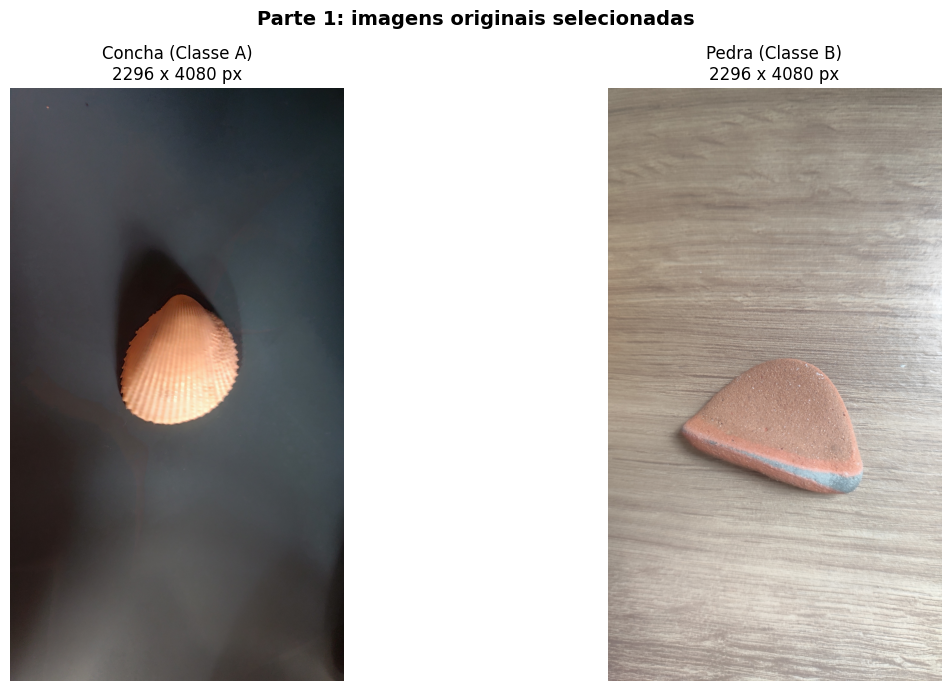

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, info in zip(axes, IMAGENS):
    arr = carregar_rgb(caminho(info))
    ax.imshow(arr)
    ax.set_title(f"{info['classe']}\n{arr.shape[1]} x {arr.shape[0]} px", fontsize=12)
    ax.axis('off')
plt.suptitle('Parte 1: imagens originais selecionadas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [9]:
# versões em tons de cinza (reduzidas) usadas em todo o pipeline de ruído e filtragem
BASE_GRAY = {info['cls']: redimensionar(carregar_gray(caminho(info))) for info in IMAGENS}
for cls, img in BASE_GRAY.items():
    print(f'{cls}: tons de cinza {img.shape[1]} x {img.shape[0]} px')


concha: tons de cinza 576 x 1024 px
pedra: tons de cinza 576 x 1024 px


### Parte 2: Inserção de ruído



#### Ruído gaussiano




Parâmetros do ruído gaussiano: média = 0, desvio padrão = 25


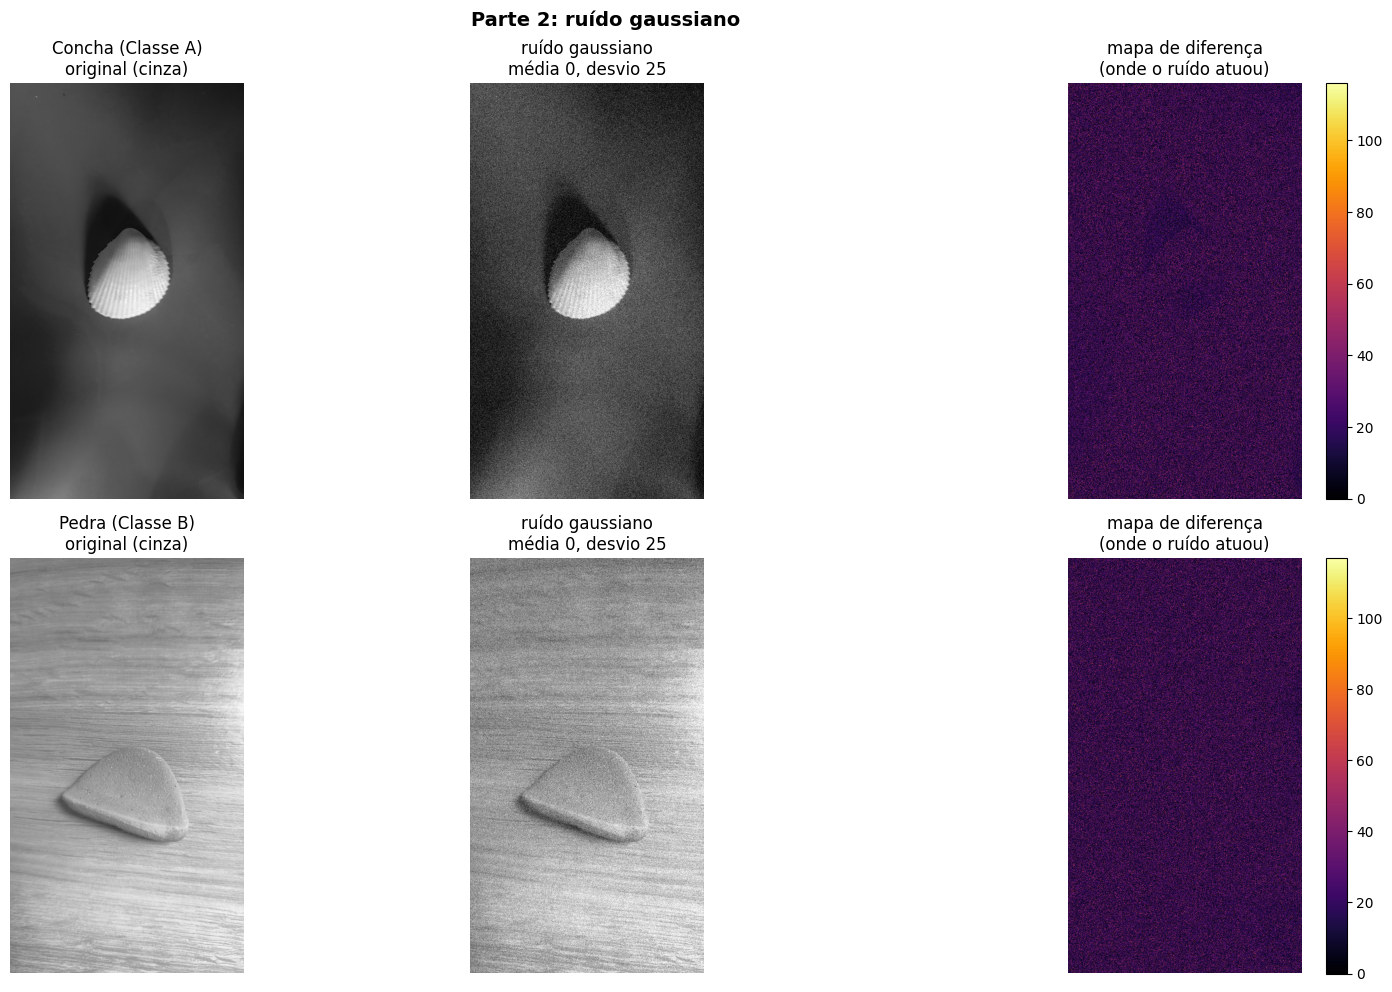

In [10]:
def ruido_gaussiano(img, media=0, desvio=25):
    ruido = np.random.normal(media, desvio, img.shape)
    return np.clip(img.astype(np.float64) + ruido, 0, 255).astype(np.uint8)


MEDIA_G, DESVIO_G = 0, 25
np.random.seed(42)
RUIDO_GAUSS = {cls: ruido_gaussiano(img, MEDIA_G, DESVIO_G) for cls, img in BASE_GRAY.items()}

print(f'Parâmetros do ruído gaussiano: média = {MEDIA_G}, desvio padrão = {DESVIO_G}')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for linha, info in enumerate(IMAGENS):
    cls = info['cls']
    base = BASE_GRAY[cls]
    ruidosa = RUIDO_GAUSS[cls]
    dif = cv2.absdiff(ruidosa, base)

    axes[linha, 0].imshow(base, vmin=0, vmax=255)
    axes[linha, 0].set_title(f'{info["classe"]}\noriginal (cinza)')
    axes[linha, 1].imshow(ruidosa, vmin=0, vmax=255)
    axes[linha, 1].set_title(f'ruído gaussiano\nmédia {MEDIA_G}, desvio {DESVIO_G}')
    im = axes[linha, 2].imshow(dif, cmap='inferno')
    axes[linha, 2].set_title('mapa de diferença\n(onde o ruído atuou)')
    for j in range(3):
        axes[linha, j].axis('off')
    fig.colorbar(im, ax=axes[linha, 2], fraction=0.046, pad=0.04)

plt.suptitle('Parte 2: ruído gaussiano', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Impacto visual observado.** A imagem ganha uma granulação fina e homogênea distribuida,
área. As regiões lisas, como o fundo, deixam de ser uniformes e passam a tremer, bordas e
texturas continuam visíveis, mas com menos nitidez.

**O ruído está distribuído uniformemente na imagem?** Todas as áreas da imagem apresentam ruído de forma parecida. O que muda é a intensidade de cada pixel: a maioria sofre uma alteração pequena e só alguns mudam bastante.

**Que problemas esse ruído pode causar para algoritmos de visão computacional?** O ruído deixa a imagem com menos sinal "limpo" e mais sujeira, e ainda cria pequenas variações falsas espalhadas por todo o quadro. Isso afeta as etapas que procuram bordas e cantos, que acabam reagindo ao ruído em vez do que importa de verdade. Também atrapalha a extração de descritores, que são os pontos característicos usados para reconhecer e comparar objetos (como SIFT e ORB), e prejudica a segmentação que separa as regiões por nível de brilho. No fim, o classificador erra mais. Como cada etapa depende da anterior, um pré-processamento malfeito vai comprometendo todo o resto do pipeline.


#### Ruído sal e pimenta

O ruído sal e pimenta troca uma fração dos pixels pelos valores extremos: metade vira branco
(sal, valor 255) e metade vira preto (pimenta, valor 0). Aqui foi usada uma probabilidade de
5% dos pixels, divididos igualmente entre sal e pimenta.


Probabilidade configurada: 5.0% dos pixels
Concha (Classe A): pixels efetivamente alterados = 4.88%
Pedra (Classe B): pixels efetivamente alterados = 4.88%


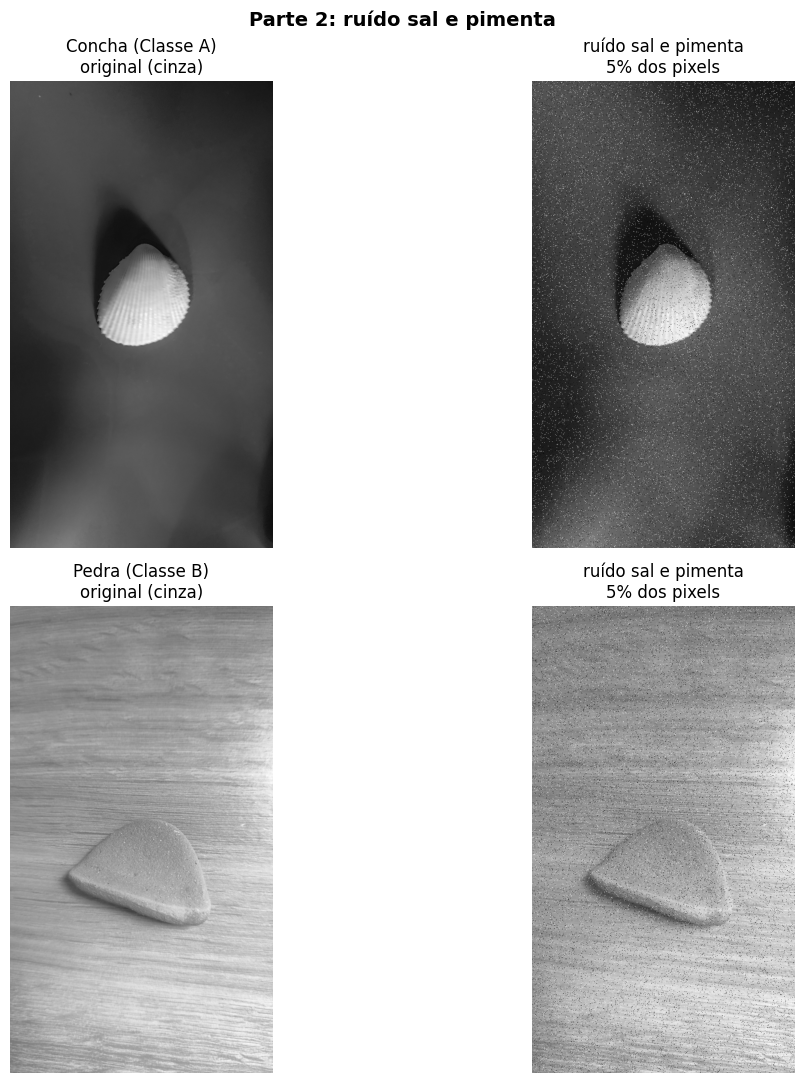

In [11]:
def ruido_sal_pimenta(img, prob=0.05):
    saida = img.copy()
    n = int(img.size * prob / 2)
    ys = np.random.randint(0, img.shape[0], n)
    xs = np.random.randint(0, img.shape[1], n)
    saida[ys, xs] = 255                      # sal
    ys = np.random.randint(0, img.shape[0], n)
    xs = np.random.randint(0, img.shape[1], n)
    saida[ys, xs] = 0                        # pimenta
    return saida


PROB_SP = 0.05
np.random.seed(7)
RUIDO_SP = {cls: ruido_sal_pimenta(img, PROB_SP) for cls, img in BASE_GRAY.items()}

print(f'Probabilidade configurada: {PROB_SP * 100:.1f}% dos pixels')
for info in IMAGENS:
    cls = info['cls']
    alterados = np.mean(RUIDO_SP[cls] != BASE_GRAY[cls]) * 100
    print(f'{info["classe"]}: pixels efetivamente alterados = {alterados:.2f}%')

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for linha, info in enumerate(IMAGENS):
    cls = info['cls']
    axes[linha, 0].imshow(BASE_GRAY[cls], vmin=0, vmax=255)
    axes[linha, 0].set_title(f'{info["classe"]}\noriginal (cinza)')
    axes[linha, 1].imshow(RUIDO_SP[cls], vmin=0, vmax=255)
    axes[linha, 1].set_title('ruído sal e pimenta\n5% dos pixels')
    for j in range(2):
        axes[linha, j].axis('off')
plt.suptitle('Parte 2: ruído sal e pimenta', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Porcentagem de pixels alterados.** A configuração usa 5% dos pixels (2,5% sal e 2,5%
pimenta). O valor medido fica um pouco abaixo de 5% porque os sorteios podem repetir a mesma
posição e porque um pixel já branco que recebe sal não muda de valor.

**Como esse ruído se diferencia visualmente do ruído gaussiano?** O gaussiano altera levemente
quase todos os pixels e produz uma granulação suave por toda a imagem. O sal e pimenta faz o
oposto: altera poucos pixels, mas de forma drástica, jogando cada um para preto ou branco puro.
resultando em  pontos isolados pretos e brancos distribuidos sobre a imagem.

**Em quais situações esse ruído aparece em sistemas reais de captura?** Costuma vir de falhas de hardware e transmissão: pixels defeituosos no sensor, erros de bit na conversão
analógico digital, interferência eletromagnética.


### Parte 3: Filtro passa-baixo

A filtragem é feita no domínio da frequência. A imagem é levada ao espectro com a transformada
de Fourier (FFT), onde o centro concentra as baixas frequências (estrutura geral e áreas lisas)
e as extremidades concentram as altas frequências (detalhes finos e ruído). O filtro passa-baixo
multiplica o espectro por uma máscara que mantém o centro e atenua as bordas, deixando passar só
as baixas frequências. São testados dois níveis de corte: um corte largo (D0 = 120, suavização
leve) e um corte estreito (D0 = 30, suavização forte). Quanto menor o raio de corte, mais
frequências são removidas e mais forte é a suavização.


#### Filtro passa-baixo em imagens com ruído sal e pimenta

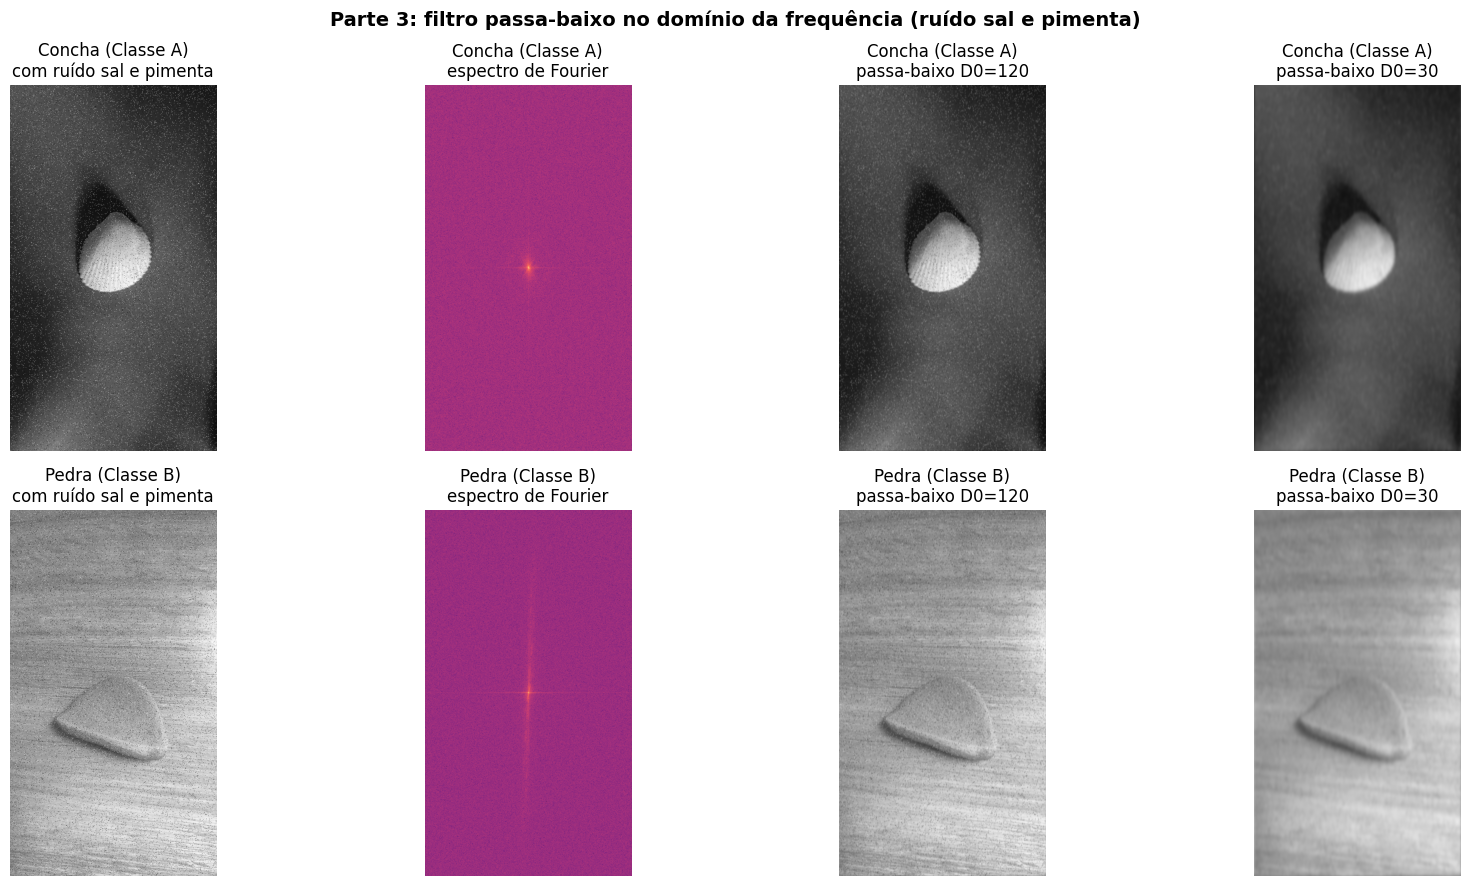

Resultados para ruído gaussiano:
           imagem              etapa  sigma ruído  energia borda
Concha (Classe A)            ruidosa        19.31           81.5
Concha (Classe A) passa-baixo D0=120         0.61           37.5
Concha (Classe A)  passa-baixo D0=30         0.24            5.8
 Pedra (Classe B)            ruidosa        19.98          103.7
 Pedra (Classe B) passa-baixo D0=120         0.62           43.2
 Pedra (Classe B)  passa-baixo D0=30         0.27            7.1


In [13]:
linhas = []
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for i, info in enumerate(IMAGENS):
    cls = info['cls']
    ruidosa = RUIDO_SP[cls]
    pb_largo = np.clip(filtro_freq(ruidosa, 120, 'baixo'), 0, 255).astype(np.uint8)
    pb_estreito = np.clip(filtro_freq(ruidosa, 30, 'baixo'), 0, 255).astype(np.uint8)

    for nome, img in [('ruidosa', ruidosa),
                      ('passa-baixo D0=120', pb_largo),
                      ('passa-baixo D0=30', pb_estreito)]:
        linhas.append({
            'imagem': info['classe'],
            'etapa': nome,
            'sigma ruído': round(estimar_ruido(img), 2),
            'energia borda': round(energia_borda(img), 1),
        })

    painel = [('com ruído sal e pimenta', ruidosa),
              ('espectro de Fourier', espectro(ruidosa)),
              ('passa-baixo D0=120', pb_largo),
              ('passa-baixo D0=30', pb_estreito)]
    for j, (titulo, img) in enumerate(painel):
        if 'espectro' in titulo:
            axes[i, j].imshow(img, cmap='magma')
        else:
            axes[i, j].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes[i, j].set_title(f'{info["classe"]}\n{titulo}')
        axes[i, j].axis('off')

plt.suptitle('Parte 3: filtro passa-baixo no domínio da frequência (ruído sal e pimenta)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

df_passabaixo = pd.DataFrame(linhas)
print("Resultados para ruído gaussiano:")
print(df_passabaixo.to_string(index=False))



#### Filtro passa-baixo em imagens com ruído guassiano

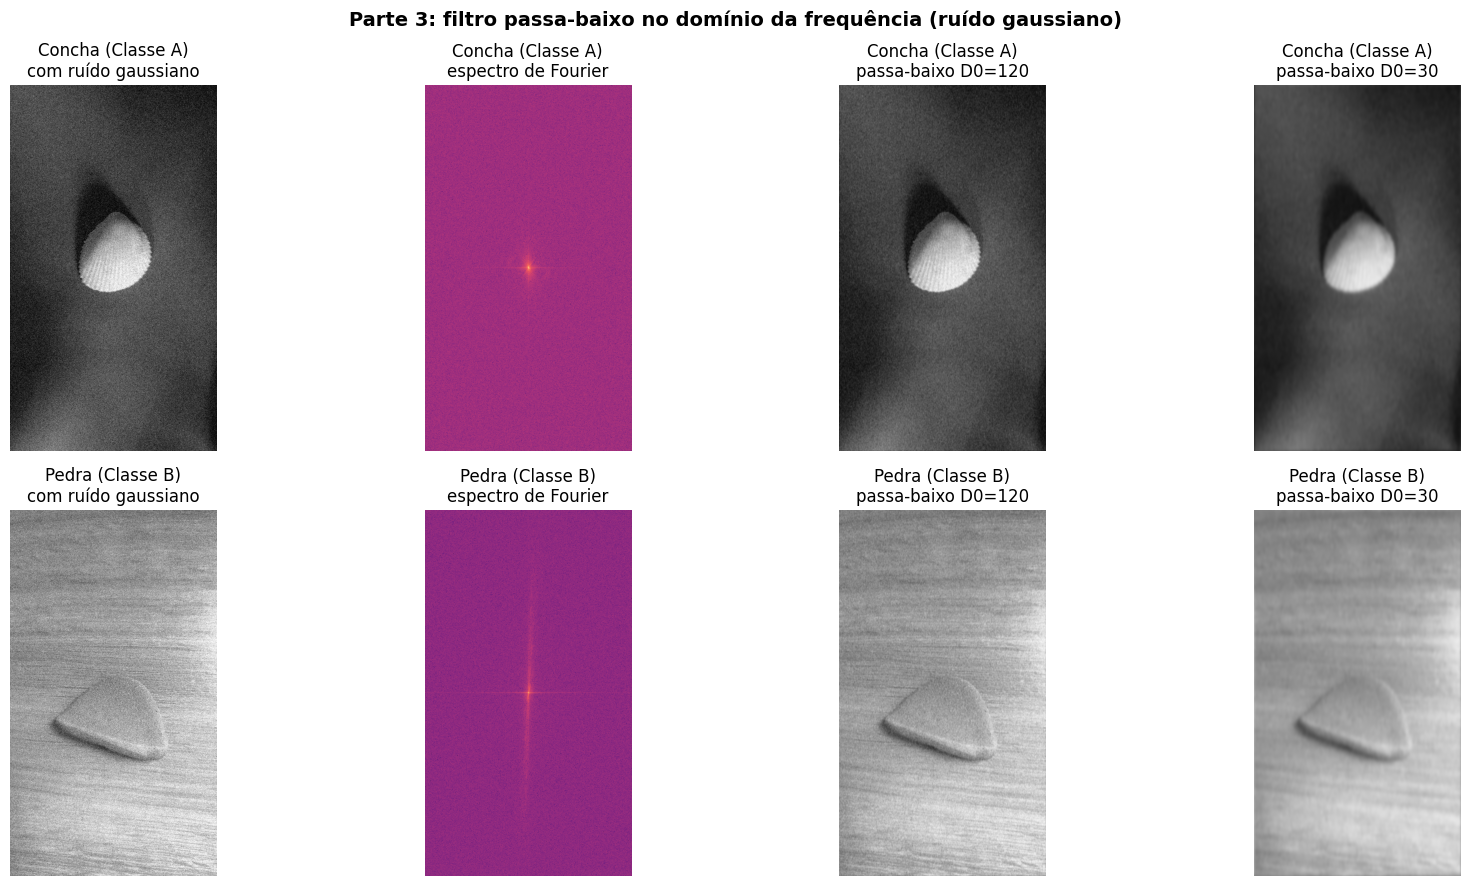

Resultados para ruído gaussiano:
           imagem              etapa  sigma ruído  energia borda
Concha (Classe A)            ruidosa        24.77          107.2
Concha (Classe A) passa-baixo D0=120         0.59           35.3
Concha (Classe A)  passa-baixo D0=30         0.23            5.2
 Pedra (Classe B)            ruidosa        25.06          115.8
 Pedra (Classe B) passa-baixo D0=120         0.60           40.4
 Pedra (Classe B)  passa-baixo D0=30         0.26            6.9


In [14]:
linhas = []
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for i, info in enumerate(IMAGENS):
    cls = info['cls']
    ruidosa = RUIDO_GAUSS[cls]
    pb_largo = np.clip(filtro_freq(ruidosa, 120, 'baixo'), 0, 255).astype(np.uint8)
    pb_estreito = np.clip(filtro_freq(ruidosa, 30, 'baixo'), 0, 255).astype(np.uint8)

    for nome, img in [('ruidosa', ruidosa),
                      ('passa-baixo D0=120', pb_largo),
                      ('passa-baixo D0=30', pb_estreito)]:
        linhas.append({
            'imagem': info['classe'],
            'etapa': nome,
            'sigma ruído': round(estimar_ruido(img), 2),
            'energia borda': round(energia_borda(img), 1),
        })

    painel = [('com ruído gaussiano', ruidosa),
              ('espectro de Fourier', espectro(ruidosa)),
              ('passa-baixo D0=120', pb_largo),
              ('passa-baixo D0=30', pb_estreito)]
    for j, (titulo, img) in enumerate(painel):
        if 'espectro' in titulo:
            axes[i, j].imshow(img, cmap='magma')
        else:
            axes[i, j].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes[i, j].set_title(f'{info["classe"]}\n{titulo}')
        axes[i, j].axis('off')

plt.suptitle('Parte 3: filtro passa-baixo no domínio da frequência (ruído gaussiano)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

df_passabaixo = pd.DataFrame(linhas)
print("Resultados para ruído gaussiano:")
print(df_passabaixo.to_string(index=False))

#### Análise

**O filtro conseguiu reduzir o ruído?** Sim. Como o ruído fica nas altas frequências (longe do centro do espectro), o passa-baixo corta justamente essa faixa e a imagem fica mais limpa. O efeito é claramente mais forte com D0=30 (corte mais agressivo) do que com D0=120, que quase não mexe na imagem. Vale notar uma diferença entre os dois ruídos: no gaussiano o resultado fica bem mais natural, enquanto no sal e pimenta o filtro não apaga os pontos de verdade, só os "borra" e transforma em manchinhas claras e escuras. Para sal e pimenta, um filtro de mediana funcionaria melhor que o passa-baixo.


**Que detalhes da imagem foram perdidos?** Os detalhes finos, que também são altas frequências e saem junto com o ruído. Na concha somem as ranhuras e a textura da casca, e as bordas ficam moles, na pedra somem as linhas e a granulação da superfície.

**Qual corte apresentou melhor equilíbrio?** É um meio-termo entre os dois. O D0=120 preserva bem os detalhes, mas deixa ruído sobrando; o D0=30 limpa bem, mas borra demais e apaga textura. Ou seja, o melhor equilíbrio está num corte intermediário entre 30 e 120.


### Parte 4: Filtro passa-alto

O filtro passa-alto é o oposto do passa-baixo no domínio da frequência: a máscara mantém as
altas frequências (as extremidades do espectro, onde estão as bordas e os detalhes finos) e
atenua as baixas (o centro).


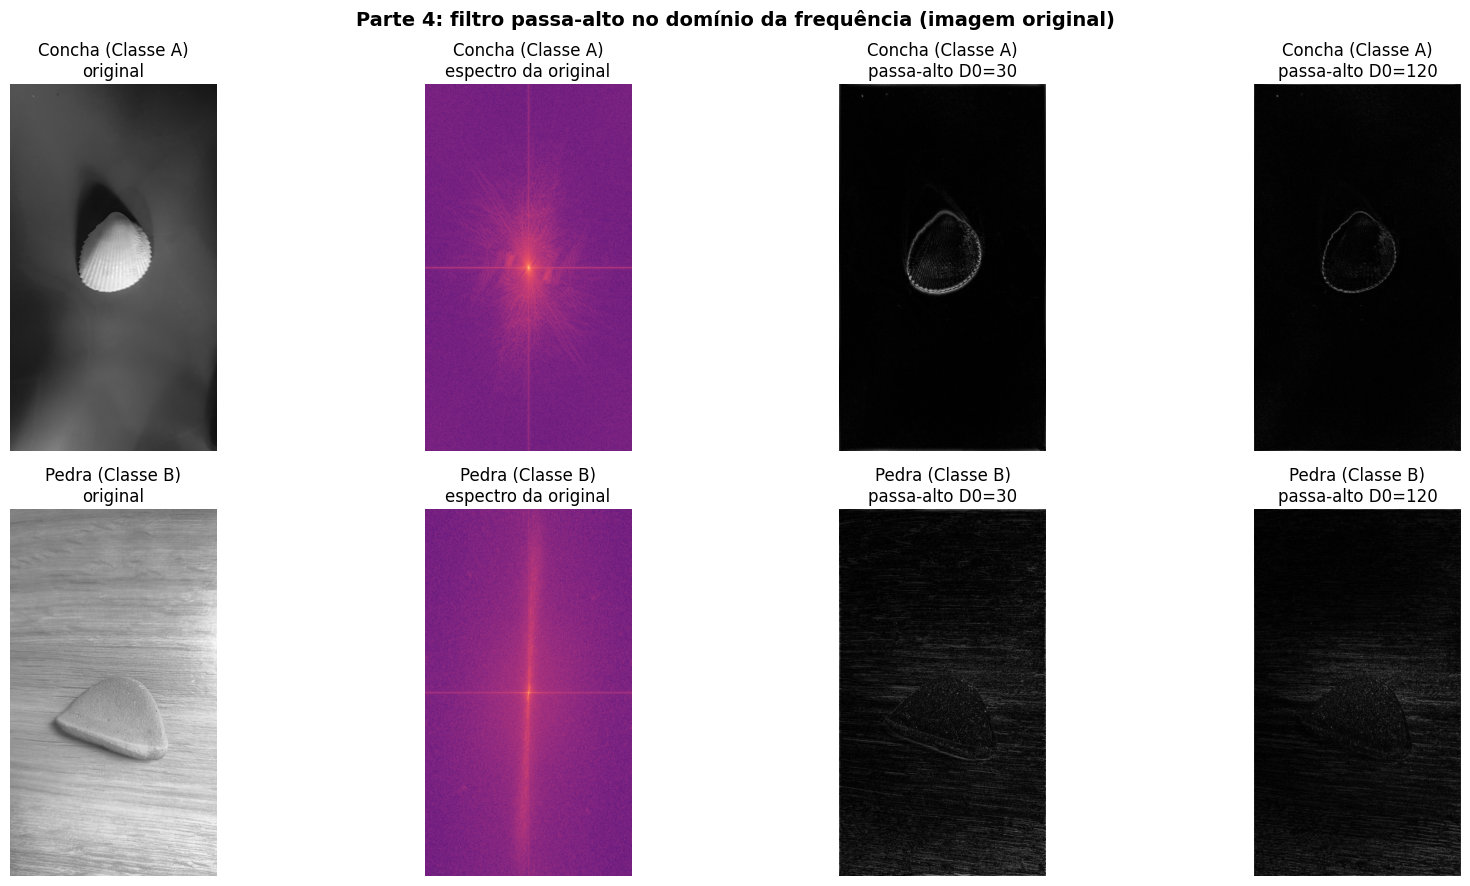

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for i, info in enumerate(IMAGENS):
    cls = info['cls']
    base = BASE_GRAY[cls]
    passa_alto = normalizar(filtro_freq(base, 30, 'alto'))
    painel = [('original', base),
              ('espectro da original', espectro(base)),
              ('passa-alto D0=30', passa_alto),
              ('passa-alto D0=120', normalizar(filtro_freq(base, 120, 'alto')))]
    for j, (titulo, img) in enumerate(painel):
        if 'espectro' in titulo:
            axes[i, j].imshow(img, cmap='magma')
        else:
            axes[i, j].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes[i, j].set_title(f'{info["classe"]}\n{titulo}')
        axes[i, j].axis('off')
plt.suptitle('Parte 4: filtro passa-alto no domínio da frequência (imagem original)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Que estruturas da imagem foram destacadas?** As bordas e os contornos do objeto, além das
transições bruscas de intensidade e da textura. As regiões lisas viram preto, porque ali não há
alta frequência para realçar. Porém na imagem da pedra o fundo de madeira tem uma frequência até mais alta que as bordas da pedra em 120 sobra mais textura da madeira que pedra.

**As bordas ficaram mais visíveis?** Sim, é exatamente o efeito principal. Como bordas são pontos de mudança rápida de intensidade (alta frequência), o passa-alto as deixa em evidência sobre o fundo escuro. A imagem perde o aspecto de foto e vira quase um "desenho de contornos". Quanto maior o D0, mais seletivo: só as bordas mais marcantes resistem, e os detalhes mais sutis somem junto.

**Esse tipo de filtro ajudaria em quais tarefas de visão computacional?** Em tarefas que dependem
de contornos e detalhes: detecção de bordas e de objetos, realce e nitidez, extração de
características, OCR, inspeção industrial e segmentação por contorno.


### Parte 5: Comparação final

A figura abaixo reúne, para uma mesma imagem, todas as etapas do experimento lado a lado.


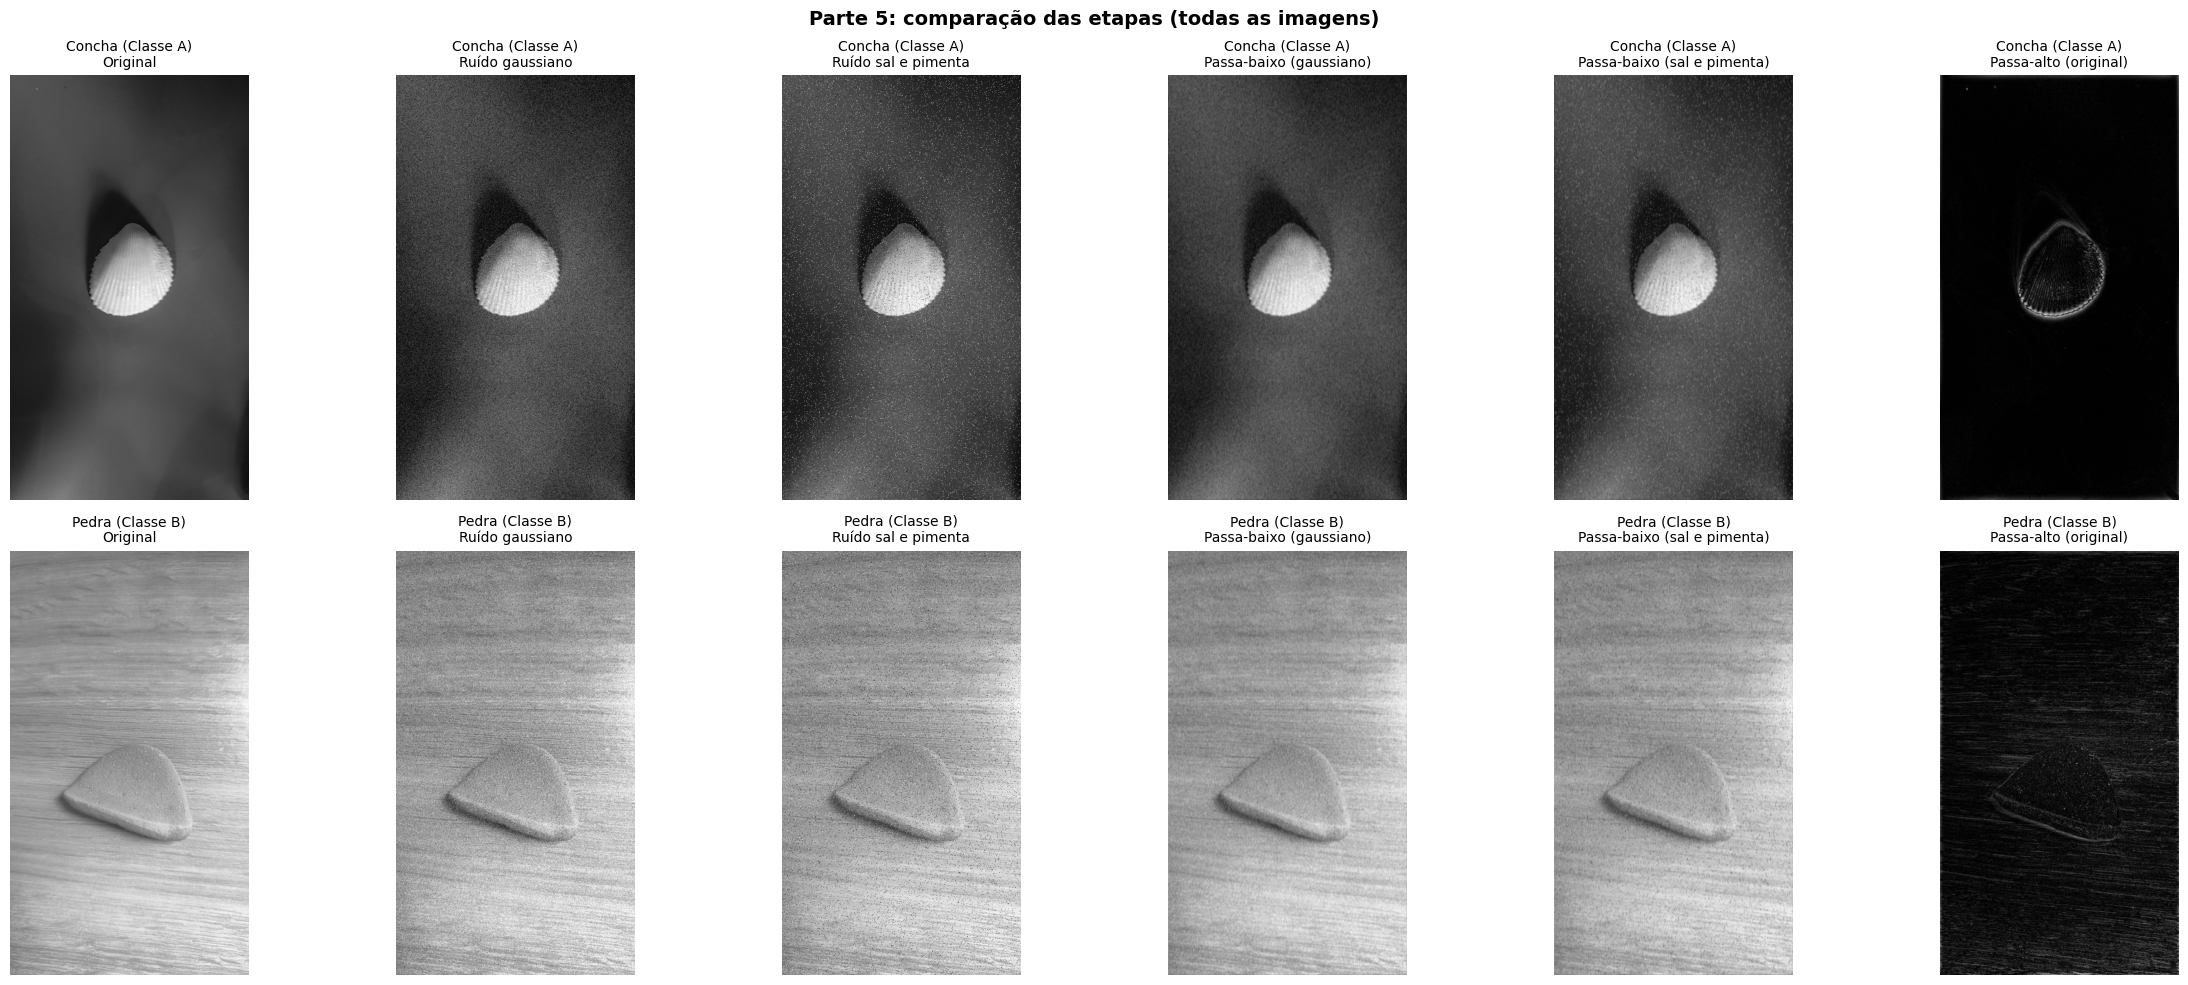

           imagem                       etapa  sigma ruído  variância  energia borda
Concha (Classe A)                    Original         1.04     1111.0            7.3
Concha (Classe A)             Ruído gaussiano        24.77     1686.0          107.2
Concha (Classe A)         Ruído sal e pimenta        19.31     1991.0           81.5
Concha (Classe A)     Passa-baixo (gaussiano)         0.59     1123.0           35.3
Concha (Classe A) Passa-baixo (sal e pimenta)         0.61     1072.0           37.5
Concha (Classe A)       Passa-alto (original)         2.29      163.0           15.8
 Pedra (Classe B)                    Original         1.95      833.0           38.5
 Pedra (Classe B)             Ruído gaussiano        25.06     1431.0          115.8
 Pedra (Classe B)         Ruído sal e pimenta        19.98     1666.0          103.7
 Pedra (Classe B)     Passa-baixo (gaussiano)         0.60      807.0           40.4
 Pedra (Classe B) Passa-baixo (sal e pimenta)         0.62      7

In [18]:
D0_BAIXO = 120
D0_ALTO = 20

estagios_defs = [
    ('Original',                  lambda cls: BASE_GRAY[cls]),
    ('Ruído gaussiano',           lambda cls: RUIDO_GAUSS[cls]),
    ('Ruído sal e pimenta',       lambda cls: RUIDO_SP[cls]),
    ('Passa-baixo (gaussiano)',   lambda cls: np.clip(filtro_freq(RUIDO_GAUSS[cls], D0_BAIXO, 'baixo'), 0, 255).astype(np.uint8)),
    ('Passa-baixo (sal e pimenta)', lambda cls: np.clip(filtro_freq(RUIDO_SP[cls], D0_BAIXO, 'baixo'), 0, 255).astype(np.uint8)),
    ('Passa-alto (original)',     lambda cls: normalizar(filtro_freq(BASE_GRAY[cls], D0_ALTO, 'alto'))),
]

n_linhas = len(IMAGENS)
n_cols = len(estagios_defs)
fig, axes = plt.subplots(n_linhas, n_cols, figsize=(4 * n_cols, 5 * n_linhas))
if n_linhas == 1:
    axes = axes.reshape(1, -1)

resumo = []
for i, info in enumerate(IMAGENS):
    cls = info['cls']
    for j, (titulo, func) in enumerate(estagios_defs):
        img = func(cls)
        axes[i, j].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes[i, j].set_title(f'{info["classe"]}\n{titulo}', fontsize=10)
        axes[i, j].axis('off')
        resumo.append({
            'imagem': info['classe'],
            'etapa': titulo,
            'sigma ruído': round(estimar_ruido(img), 2),
            'variância': round(float(img.var()), 0),
            'energia borda': round(energia_borda(img), 1),
        })

plt.suptitle('Parte 5: comparação das etapas (todas as imagens)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

df_final = pd.DataFrame(resumo)
print(df_final.to_string(index=False))

#### Análise

**Qual ruído degradou mais a imagem?**
O sal e pimenta é o que mais agride visualmente, porque ele troca pixels inteiros por preto ou branco puro, criando pontos bem fortes e isolados que saltam aos olhos. O gaussiano degrada de forma mais "suave e espalhada".

**O passa-baixo recuperou a qualidade visual?**
Em parte. Para o ruído gaussiano ele funciona melhor : como o ruído está nas altas frequências, o passa-baixo suaviza a granulação e devolve um aspecto mais limpo, com o custo de borrar um pouco as bordas e a textura. Para o sal e pimenta o resultado é pior: o filtro não apaga os pontos de verdade, só suaviza tornando-os manchinhas claras e escuras. Nesse caso o ideal seria um filtro de mediana, que remove os impulsos sem borrar tanto.

**Em quais aplicações é importante filtrar antes do processamento?**
Em qualquer pipeline onde o ruído estraga as etapas seguintes, por exemplo:

Imagem médica (radiografia, tomografia), onde ruído pode esconder ou imitar achados.
Detecção de bordas e segmentação, que respondem ao ruído e geram contornos falsos se a imagem estiver suja.
Extração de características e pontos de interesse.
OCR e reconhecimento de padrões, onde ruído atrapalha a leitura de texto e formas.
Inspeção de defeitos em linha de produção, para não confundir ruído com falha real.


## Conclusão

Este trabalho mostrou, na prática, como o ruído atrapalha uma imagem e como os filtros ajudam a recuperá-la. Vimos que o ruído aparece sempre nos detalhes finos da imagem (as altas frequências), enquanto as áreas mais lisas ficam no centro do espectro. Com isso, o filtro passa-baixo limpa o ruído e deixa a imagem mais suave, e o passa-alto faz o contrário, destacando bordas e contornos.  Cada ruído pede uma resposta diferente assim como cada objetivo de pipeline.
